### Examen Parcial 1

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import skew
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("clientes_retailplus.csv")

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         3000 non-null   int64  
 1   Age                 2922 non-null   float64
 2   Gender              2940 non-null   object 
 3   Income              2882 non-null   float64
 4   City_Type           3000 non-null   object 
 5   Online_Purchases    3000 non-null   int64  
 6   Store_Purchases     3000 non-null   int64  
 7   Avg_Ticket          3000 non-null   float64
 8   Total_Spending      3000 non-null   float64
 9   Membership_Years    3000 non-null   float64
 10  Returns_Rate        2931 non-null   float64
 11  Satisfaction_Score  2850 non-null   float64
dtypes: float64(7), int64(3), object(2)
memory usage: 281.4+ KB


In [12]:
print(data.isnull().any().sum())


5


In [ ]:
total_missing = data.isnull().sum().sum()
total_valores = data.size
porcentaje = (total_missing / total_valores * 100).round(2)
print(f"Porcentaje total de missing values: {porcentaje}%")

Porcentaje total de missing values: 1.0%


In [ ]:
print(data.duplicated().sum())

0


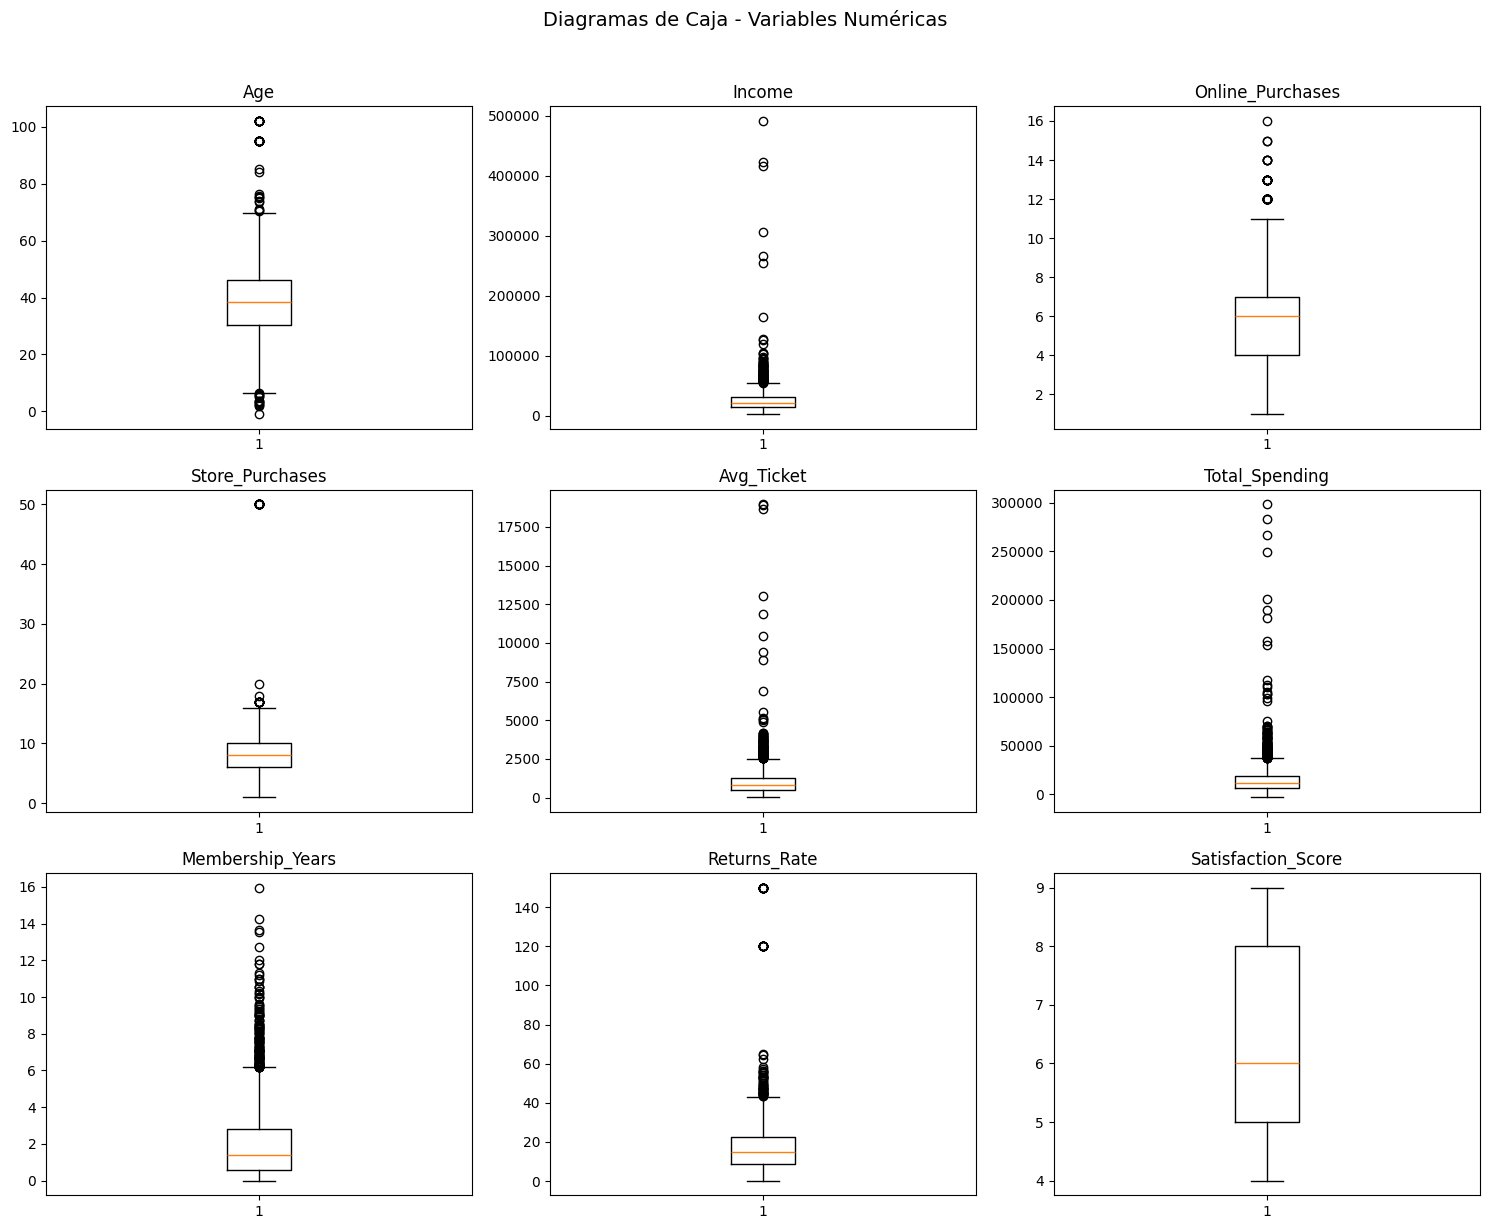

In [15]:
# Variables numéricas excluyendo Customer_ID
num_vars = data.select_dtypes(include=['int64','float64']).columns.tolist()
num_vars = [v for v in num_vars if v != 'Customer_ID']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    axes[i].boxplot(data[var].dropna())
    axes[i].set_title(var)
    axes[i].set_xlabel('')

# Ocultar subplots vacíos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Diagramas de Caja - Variables Numéricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
#Definir numeric_columns
numerical_columns = [v for v in data.select_dtypes(include=['int64','float64']).columns if v != 'Customer_ID']

# Calcula la simetría/asimetría para todas las variables numéricas, excluyendo Customer_ID. ¿Cuántas de las variables presetan una asimetría fuerte?
skewness_values = data[numerical_columns].apply(skew, nan_policy='omit').sort_values(ascending=False)
skewness_values

Income                10.134726
Avg_Ticket             7.661900
Total_Spending         7.326624
Store_Purchases        5.633503
Returns_Rate           4.600302
Membership_Years       1.907117
Age                    0.824786
Online_Purchases       0.495623
Satisfaction_Score     0.006744
dtype: float64

In [23]:
#¿Cuántas de las variables presetan una asimetría fuerte?
fuertes = (skewness_values.abs() >= 1).sum()
print(f"Variables con asimetría fuerte (|skew| ≥ 1): {fuertes}")
print(skewness_values[skewness_values.abs() >= 1])

Variables con asimetría fuerte (|skew| ≥ 1): 6
Income              10.134726
Avg_Ticket           7.661900
Total_Spending       7.326624
Store_Purchases      5.633503
Returns_Rate         4.600302
Membership_Years     1.907117
dtype: float64


In [24]:
Q1 = data['Income'].quantile(0.25)
Q3 = data['Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_income = data[(data['Income'] < lower) | (data['Income'] > upper)]
print(f"Outliers en Income: {len(outliers_income)}")
print(f"Límite inferior: {lower:,.0f}")
print(f"Límite superior: {upper:,.0f}")

Outliers en Income: 120
Límite inferior: -8,718
Límite superior: 55,570


In [25]:
# Eliminamos los outliers de la variable income utilizando el método del rango intercuartílico (IQR)
Q1 = data['Income'].quantile(0.25)
Q3 = data['Income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data_cleaned_no_outliers = data[(data['Income'] >= lower_bound) & (data['Income'] <=upper_bound)]
# Calculamos la mediana de la variable income redondeada a dos decimales
median_income = data_cleaned_no_outliers['Income'].median()
print(f"La mediana de la variable Income es: {median_income:.2f}")

La mediana de la variable Income es: 21275.97


In [29]:
print(data['Gender'].value_counts())
print(f"\nGénero más frecuente: {data['Gender'].mode()[0]}")

Gender
Female    1588
Male      1352
Name: count, dtype: int64

Género más frecuente: Female


In [30]:
moda_gender = data['Gender'].mode()[0]
data['Gender'] = data['Gender'].fillna(moda_gender)
print(f"Moda de Gender: {moda_gender}")
print(f"Missing values restantes en Gender: {data['Gender'].isna().sum()}")

Moda de Gender: Female
Missing values restantes en Gender: 0


In [31]:
original = len(data)
limpio = len(data_cleaned_no_outliers)
perdidas = original - limpio
porcentaje = (perdidas / original) * 100

print(f"Observaciones originales: {original}")
print(f"Observaciones después de limpieza: {limpio}")
print(f"Observaciones perdidas: {perdidas}")
print(f"Porcentaje perdido: {porcentaje:.2f}%")

Observaciones originales: 3000
Observaciones después de limpieza: 2762
Observaciones perdidas: 238
Porcentaje perdido: 7.93%


In [33]:
promedio_mujeres_online = data_cleaned_no_outliers[data_cleaned_no_outliers['Gender'] == 'Female']['Online_Purchases'].mean()
print(f"Promedio de compras online de mujeres: {promedio_mujeres_online:.2f}")

Promedio de compras online de mujeres: 6.10


In [37]:
promedio_ticket_genero = data_cleaned_no_outliers.groupby('Gender')['Avg_Ticket'].mean().round(2)
print(promedio_ticket_genero)

Gender
Female    1017.08
Male      1040.31
Name: Avg_Ticket, dtype: float64


In [39]:
gasto_hombres = data_cleaned_no_outliers[data_cleaned_no_outliers['Gender'] == 'Male']['Total_Spending'].mean()
print(f"Gasto total promedio de los hombres: {gasto_hombres:.2f}")

Gasto total promedio de los hombres: 14983.28


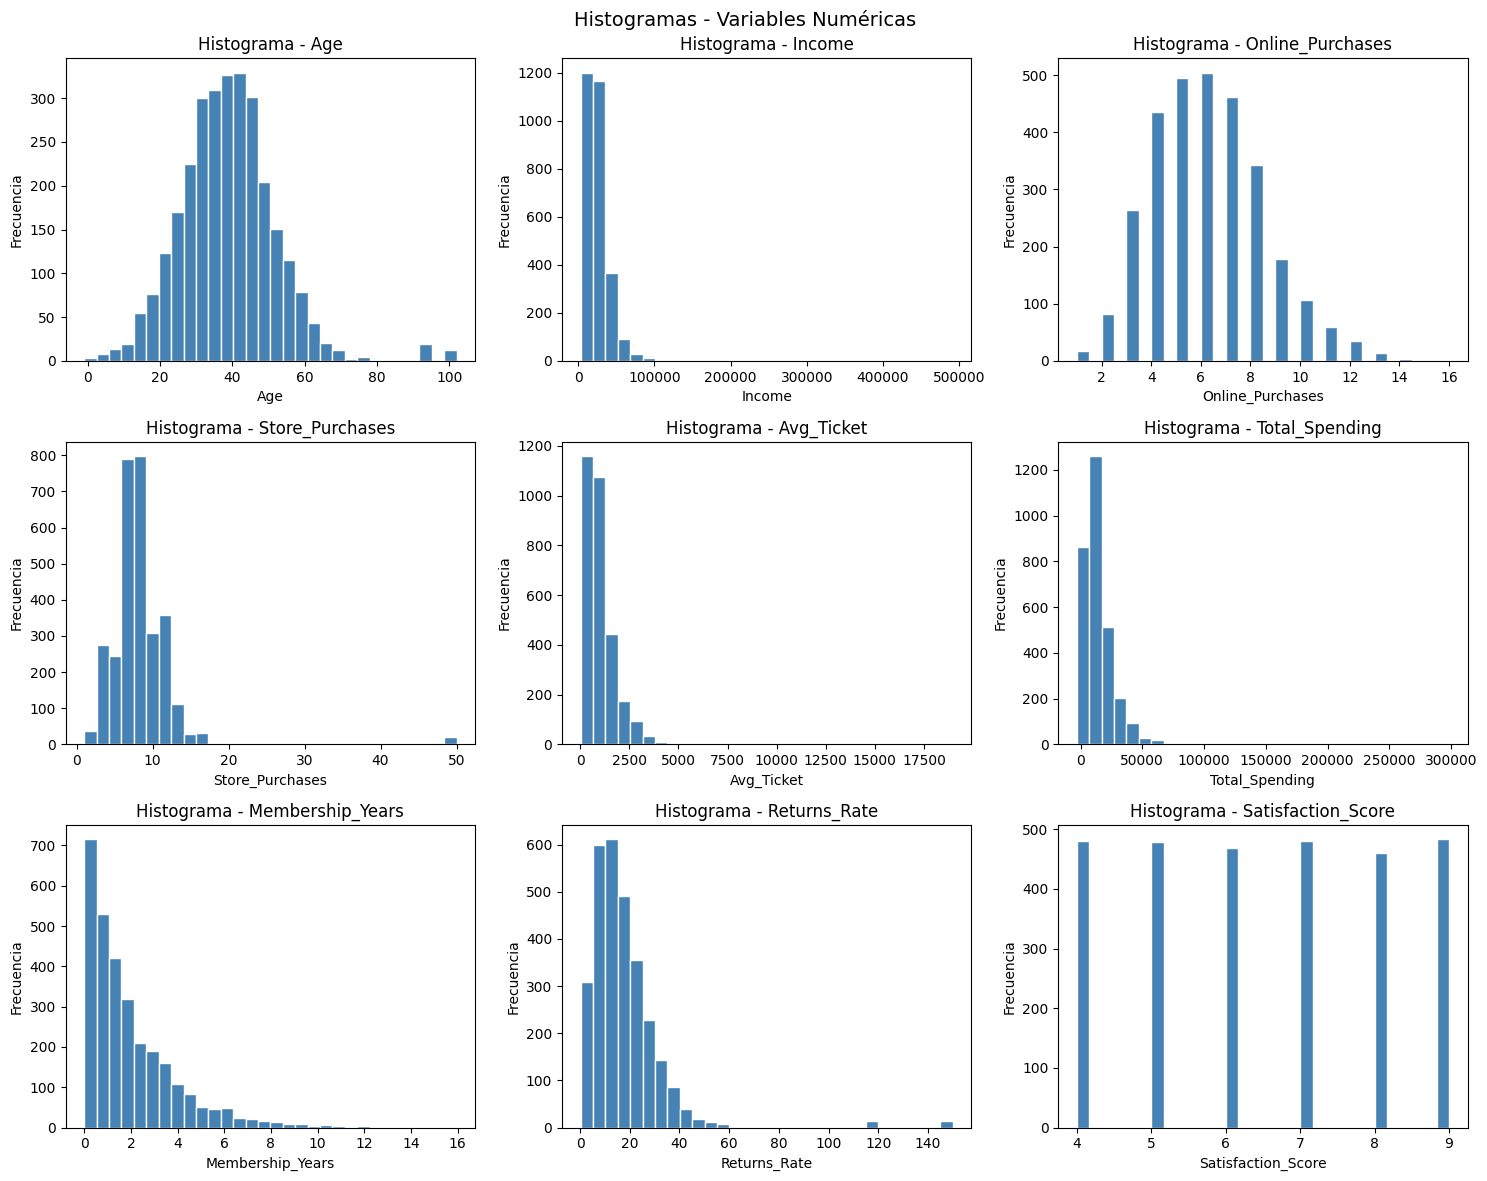

In [40]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(numerical_columns):
    axes[i].hist(data[var].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Histograma - {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas - Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

##